<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_MLR/17_2_1_3_MLR_Ames_Part3_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLR Predicting Housing Prices in Ames, Iowa: Regularization
## Ridge, Lasso, and Elastic Net on All 225 Features

## Introduction

Part 2 ended on a high note with an asterisk. We built a model with roughly 20 features and a test R² around 0.93 — but look at how we got there. First a correlation filter cut 225 features down to 40, and we already know that filter plays favorites: one-hot dummy columns show weak individual correlations with the target even when they matter as a group, so most of the neighborhood information was probably gone before selection even started. Then stepwise selection made a series of greedy choices, and stepwise never changes its mind — a feature added early stays in, a feature passed over never gets a second look. The result is a good model. It is not a guaranteed best model, and we can't easily say what we lost along the way.

This notebook makes the opposite bet: **don't discard anything.** Keep all 225 features and, instead of deciding which ones are in or out, put a *penalty* on coefficient size and let every feature fight for whatever influence it can justify. That is **regularization**, and it comes in three flavors we'll meet in turn: **Ridge**, **Lasso**, and **Elastic Net**.

Along the way we will:

* Build a **Pipeline**-based evaluation workflow that scales features without leaking information across CV folds
* Report errors in **actual dollars**, not log units (the "Log-Dollar Illusion" fix)
* Answer the question hanging over the whole notebook: can regularization on all 225 features match or beat Part 2's hand-built ~0.93?

---

### Imports and Environment Setup
The standard stack, plus the regularized regressors and preprocessing tools from `sklearn`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Pipeline tools
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Linear Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Settings
%matplotlib inline
pd.set_option('display.max_columns', None)

### Data Loading
One line, thanks to Part 1: `load_and_clean_ames()` replays every cleaning decision we made there. As before, the target is the **log** of sale price — remember what that means for reading any error number the model produces (we'll deal with it head-on shortly).

In [2]:
import os
import warnings

warnings.filterwarnings('ignore')

# Download the cleaning module from GitHub
import urllib.request
module_url = "https://raw.githubusercontent.com/bsheese/cs377/main/17_regression_crossval/17_2_MLR/ames_cleaning.py"
urllib.request.urlretrieve(module_url, "ames_cleaning.py")
from ames_cleaning import load_and_clean_ames

data_url = 'https://raw.githubusercontent.com/bsheese/cs377/main/data/data_housing_ames.txt'
X_train, X_test, y_train, y_test = load_and_clean_ames(data_url)
print(f"Cleaned X_train shape: {X_train.shape}")
print(f"Cleaned X_test shape: {X_test.shape}")

Cleaned X_train shape: (2340, 225)
Cleaned X_test shape: (585, 225)


## The 225-Feature Headache

Look at those shapes: 2,340 training houses, 225 columns. That's one coefficient to estimate for roughly every ten houses we've ever seen. Run ordinary OLS on this and it will use *every single column* — the genuinely informative ones, the marginal ones, and the ones that are pure noise — because nothing in OLS's objective says "maybe don't." With this many degrees of freedom, some of those noise columns *will* fit quirks of our particular 2,340 houses, and that fit will not survive contact with new data.

Before we can fix that, we need to be able to *measure* it honestly. That's the next section's job.

## Building an Honest Evaluation Workflow

Two problems stand between us and trustworthy numbers, and both have bitten us before.

**Leakage through the scaler.** Regularization (for reasons coming shortly) requires standardized features. The tempting workflow — scale the whole training set, then cross-validate — is subtly broken: the scaler computes means and standard deviations from *all* the data, including the rows that will later serve as validation folds. Each fold is then judged on data that helped set the scaling. The fix is the same idea as Part 1's train/test discipline, applied *inside* cross-validation: bundle the `StandardScaler` and the model into a `Pipeline`, and let CV fit the scaler on the training folds only, fold by fold. Same code, honest numbers.

**The Log-Dollar Illusion.** Our model predicts log-price, so its native RMSE comes out as something like `0.12` — mathematically fine, and meaningless to any human who prices houses for a living. Before reporting, we convert predictions back to dollars with `np.exp()` and compare them to actual sale prices. An error of "\$13,000 on a typical house" is something a stakeholder can act on; "0.12 log-units" is not.

The function below bakes both fixes into one reusable evaluation engine: give it any linear model, it wraps the model in a pipeline, cross-validates, and reports metrics in real dollars.

In [3]:
def run_evaluation_pipeline(model, X, y, model_name="Model"):
    """
    Standardizes data, runs cross-validation, and returns
    HONEST (Cross-Validated) RMSE/MAE in actual US Dollars.
    """

    # 1. Create the Pipeline
    # This ensures StandardScaler only "sees" the training folds during CV,
    # preventing data leakage.
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])

    # 2. Calculate Technical CV Log-RMSE
    # This is the standard metric for comparing models in log-space.
    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_squared_error')
    cv_rmse_log = np.sqrt(-cv_scores.mean())

    # 3. Generate "Honest" Predictions (Cross-Val Predict)
    # Instead of predicting on the training data, this generates a prediction
    # for every house using a model that DID NOT see that house during training.
    log_cv_preds = cross_val_predict(pipe, X, y, cv=5)

    # 4. Transform back to Actual US Dollars
    # We must exponentiate both the predictions and the actual target.
    real_cv_preds = np.exp(log_cv_preds)
    real_y_actual = np.exp(y)

    # 5. Calculate Real-World Metrics (Validation Error)
    # These metrics represent your expected error on a new house listing.
    mae_dollars = mean_absolute_error(real_y_actual, real_cv_preds)
    rmse_dollars = np.sqrt(mean_squared_error(real_y_actual, real_cv_preds))

    # 6. Final Fit
    # We fit on the entire provided dataset so the returned pipeline is ready for use.
    pipe.fit(X, y)

    print(f"--- {model_name} (Validation Metrics) ---")
    print(f"CV Log-RMSE:      {cv_rmse_log:.4f}")
    print(f"Real-Dollar MAE:  ${mae_dollars:,.2f}")
    print(f"Real-Dollar RMSE: ${rmse_dollars:,.2f}")
    print("-" * 35)

    return pipe, mae_dollars

---

### The OLS Baseline

Every technique in this notebook has to beat something. Here is the something: plain OLS, all 225 features, no penalty. This is the "use everything, trust everything" model the 225-feature headache warned us about.

In [4]:
# Initialize a standard Linear Regression model
ols_model = LinearRegression()

# Run the evaluation
ols_pipe, ols_mae = run_evaluation_pipeline(ols_model, X_train, y_train, "OLS (Baseline)")

--- OLS (Baseline) (Validation Metrics) ---
CV Log-RMSE:      0.1223
Real-Dollar MAE:  $13,394.12
Real-Dollar RMSE: $19,853.92
-----------------------------------


Two numbers worth fixing in your mind before we move on:

* **Real-Dollar MAE ≈ \$13,394.** On average, the unpenalized model misses a house's price by about that much. This is the target every regularized model must beat.
* **CV Log-RMSE ≈ 0.1223.** Less human-readable, but it's the honest cross-validated version — if a model's training error looks much better than this, the gap is overfitting.

Now let's tax the model for its complexity and see if the numbers improve.

## Regularization: A Budget for Coefficients

Left to itself, a regression model has exactly one goal — minimize training error — and it will pursue that goal with any coefficients it takes, including enormous ones. Enormous coefficients are a warning sign: they usually mean the model is balancing huge positive and negative weights against each other to chase noise, and they make predictions unstable — a small change in an input swings the output wildly. **Regularization** adds a second term to the model's objective: a penalty (think of it as a tax) on coefficient size. Now the model must compromise between fitting the data and keeping its coefficients small. It's a budget, and budgets force prioritization: spend your coefficient budget on the features that genuinely earn it.

This is aimed at the same problem stepwise selection tackled in Part 2 — too many features, not all of them trustworthy — but it solves it in a fundamentally different, and mostly better, way.

Stepwise selection is *binary and harsh*: a feature is 100% in or 100% out. Regularization is a volume knob instead of a mute button — a marginally useful feature keeps a small coefficient rather than being silenced entirely. Stepwise is *unstable*: change a handful of training rows and the greedy path can select a completely different feature set, whereas a penalty applied to all features at once shifts smoothly. Stepwise handles *correlated features* badly — faced with `Garage Area` and `Garage Cars` it picks one on a razor-thin margin and dumps the other, while Ridge (as we're about to see) lets them share the credit. And stepwise is *slow*: it trains and compares hundreds of models one feature at a time. The first time we ran forward selection on the full Ames feature set with cross-validation, it took 90 minutes. The regularized models below reach nearly identical answers in seconds.

We'll see regularization again later in the course in entirely different model families — the idea of penalizing complexity is one of machine learning's most reusable moves.

## Ridge Regression (L2)

Start with the failure Ridge was invented for. Our data still contains overlapping features — Part 1 deliberately left `Log_Gr Liv Area` overlapping with `Total_Square_Footage`, and the one-hot columns add more entanglement. When two features carry nearly the same information, OLS cannot decide which one deserves the credit, and the math becomes unstable: a slight change in the training data can flip a coefficient from +50,000 to −50,000, with the twin feature swinging the opposite way to compensate. The predictions barely change; the *coefficients* become meaningless.

Ridge fixes this by taxing the **squared** value of every coefficient. (The name "L2" comes from the $L^2$ norm — the linear-algebra term for straight-line distance, computed by summing squares — but the intuition is all in the word *squared*.) Squaring means big coefficients are punished disproportionately: a coefficient of 100 costs ten thousand times more tax than a coefficient of 1. The +50,000/−50,000 standoff becomes prohibitively expensive, so correlated features settle into small, shared, stable weights instead.

One dial controls the strictness: **alpha ($\alpha$)** — you'll also see it called lambda in textbooks. At $\alpha = 0$ there is no tax and Ridge *is* OLS. As $\alpha$ grows, coefficients are squashed harder toward zero. But — and this matters for what comes next — Ridge shrinks coefficients *asymptotically* toward zero and never lands exactly on it. Feed Ridge 225 features and you get back a model with all 225 features, every one of them smaller.

That property cuts both ways. If lots of features each carry a little real signal, keeping all of them (shrunken) is exactly right — and if your domain or your regulator requires every variable to stay in the model, Ridge guarantees it. But Ridge will never *simplify* your model for you. Two more costs apply to everything in this notebook: because the penalty acts on coefficient *size*, features must be standardized first (otherwise a variable measured in acres gets taxed differently than the same variable in square feet — this is why the `StandardScaler` lives in our pipeline), and shrunken coefficients are deliberately *biased*, so you can no longer read them as literal dollar effects. We trade interpretive purity for stability.

*Historical note: Ridge dates to the 1970s, with roots in Soviet mathematics of the 1940s. Optional reading: https://en.wikipedia.org/wiki/Ridge_regression*

In [5]:
# Initialize Ridge with an alpha (penalty strength) of 100
# Note: We are 'guessing' alpha=100 for now; we will tune this later.
ridge_model = Ridge(alpha=100)

# Run the evaluation
ridge_pipe, ridge_mae = run_evaluation_pipeline(ridge_model, X_train, y_train, "Ridge (L2)")


--- Ridge (L2) (Validation Metrics) ---
CV Log-RMSE:      0.1204
Real-Dollar MAE:  $13,286.88
Real-Dollar RMSE: $19,712.42
-----------------------------------


**Note on alpha:** the $\alpha = 100$ here is a placeholder, not a considered choice — we need *some* value to demonstrate the mechanics, and finding the right one systematically is the entire subject of Part 4.

**Reminder:** the `StandardScaler` in the pipeline isn't optional for Ridge — the penalty is only fair if all features are on the same scale.

---

## Lasso Regression (L1)

Ridge left us with one itch: 225 features in, 225 features out. **Lasso** (Least Absolute Shrinkage and Selection Operator) scratches it.

The change looks tiny on paper. Ridge taxes the *squared* coefficients; Lasso taxes their **absolute values**. But that small change in the tax code produces a dramatic change in behavior: where Ridge shrinks weak coefficients asymptotically close to zero, Lasso pushes them to **exactly 0.0** — and a feature with a zero coefficient has simply left the model. Lasso doesn't just shrink; it *selects*. Feed it 225 features and it hands you back the subset it considers worth paying for, with everything else deleted.

The same alpha dial applies, with a more theatrical range: at $\alpha = 0$ it's OLS; as $\alpha$ rises, more and more features get zeroed out; crank it high enough and Lasso will drop *every* predictor, leaving you a model that just predicts the intercept.

The price of the free feature selection comes in two installments. First, the standardization requirement is even more of a trap here: on unscaled data, Lasso will happily *eliminate* variables merely for being measured in large units. Second, when two features are highly correlated, Lasso's choice between them is essentially arbitrary — it keeps whichever wins by a hair and zeroes the other, even if the dropped one was the version a human would find more meaningful. (Remember this arbitrariness; it's the exact flaw Elastic Net was invented to fix.) The biased-slopes and alpha-tuning caveats from Ridge apply here unchanged.

*Optional reading on the history and mathematics: https://en.wikipedia.org/wiki/Lasso_(statistics)*

In [6]:
# Initialize Lasso with a small alpha (Lasso is very sensitive in log-space)
lasso_model = Lasso(alpha=0.005)

# Run the evaluation
lasso_pipe, lasso_mae = run_evaluation_pipeline(lasso_model, X_train, y_train, "Lasso (L1)")

# Check how many features Lasso "kept" (non-zero coefficients)
lasso_coefs = lasso_pipe.named_steps['regressor'].coef_
kept_features = np.sum(lasso_coefs != 0)
print(f"Lasso kept {kept_features} out of {X_train.shape[1]} features.")

--- Lasso (L1) (Validation Metrics) ---
CV Log-RMSE:      0.1206
Real-Dollar MAE:  $13,712.45
Real-Dollar RMSE: $20,392.10
-----------------------------------
Lasso kept 66 out of 225 features.


---

## Elastic Net: The Hybrid

Here's the dilemma the first two penalties leave us with. Give the model twin features — say, two versions of basement size — and **Lasso flips a coin**: one twin stays, one is deleted, and which is which can change with the training sample. **Ridge keeps both**, splitting the credit stably — but by the same token it keeps *everything*, useful or not.

**Elastic Net** applies both taxes at once, which turns the either/or into a dial: the **`l1_ratio`** mixing parameter slides from 0.0 (pure Ridge) through 0.5 (an even blend) to 1.0 (pure Lasso). Tuned well, it behaves like Ridge *within* a group of correlated features — keeping the group and shrinking it together — while still acting like Lasso on genuinely useless features, zeroing them out entirely.

*Historical note: invented by Hui Zou and Trevor Hastie in 2005, motivated by genetics — Lasso kept arbitrarily deleting genes that belonged to the same biological pathway as a kept gene. Elastic Net keeps the pathway. It also handles the "more columns than rows" regime (10,000 genes, 500 patients) where OLS and Lasso break down, which is why it remains a favorite in genomics and bioinformatics. Optional reading: https://en.wikipedia.org/wiki/Elastic_net_regularization*

Nothing is free: Elastic Net's flexibility doubles the tuning problem. Ridge and Lasso each ask for one number ($\alpha$); Elastic Net asks for two ($\alpha$ *and* `l1_ratio`), turning a one-dimensional search into a grid. And it remains a linear model — the best *linear* model you can buy still assumes straight-line relationships, and when that assumption is the bottleneck, no penalty will save it (that's where the tree-based models later in the course come in).

**Note on l1_ratio:** the mixing dial —
- `l1_ratio = 0`: pure Ridge (L2 only)
- `l1_ratio = 1`: pure Lasso (L1 only)
- `l1_ratio = 0.5`: an even blend (our placeholder here)

Like alpha, this gets tuned properly in Part 4.

In [7]:
# Initialize Elastic Net
en_model = ElasticNet(alpha=0.01, l1_ratio=0.5)

# Run the evaluation
en_pipe, en_mae = run_evaluation_pipeline(en_model, X_train, y_train, "Elastic Net")

--- Elastic Net (Validation Metrics) ---
CV Log-RMSE:      0.1205
Real-Dollar MAE:  $13,716.00
Real-Dollar RMSE: $20,402.25
-----------------------------------


## Model Comparison

Four models, one honest evaluation engine, one question: who wins? While the log-RMSE is the technically pure comparison, the **dollar MAE** is the number we'd put in front of a client — so that's how we'll rank them. After the leaderboard, we'll look under the hood of the winner with a residual plot to see where it still struggles.

In [8]:
results = pd.DataFrame({
    'Model': ['OLS Baseline', 'Ridge', 'Lasso', 'Elastic Net'],
    'MAE (Dollars)': [ols_mae, ridge_mae, lasso_mae, en_mae]
})

# Sort by performance
results = results.sort_values(by='MAE (Dollars)').reset_index(drop=True)
print(results)

          Model  MAE (Dollars)
0         Ridge   13286.876666
1  OLS Baseline   13394.117569
2         Lasso   13712.450381
3   Elastic Net   13715.995554


### Reading the Leaderboard

**Ridge wins — barely.** Its \$13,287 MAE beats the OLS baseline's \$13,394 by about \$107 per house. Modest, but exactly the mechanism we predicted: Ames is full of correlated features, OLS wastes variance fighting over credit assignment, and Ridge's shared-credit shrinkage steadies it.

**Lasso and Elastic Net lost to plain OLS.** That should surprise you — the fancier tools came last. The output gives the clue: *Lasso kept 66 of 225 features.* At our guessed alpha, Lasso deleted 159 columns. The Ames market appears to be built out of many small signals — dozens of features each worth a few hundred dollars — and Lasso's aggressive pruning threw away enough of them to hurt. Ridge kept all 225, shrunken, and profited. Elastic Net at a 50/50 blend inherited most of Lasso's haircut and landed in the same place.

**But hold the verdict.** Every alpha in this comparison was a guess. There is almost certainly a better alpha for Ridge than our placeholder, and Lasso's ranking in particular is an artifact of tuning — with the right penalty strength, its 66-feature model might keep the *right* features. We have reached the limit of what guessing can do; finding those values systematically is Part 4's **grid search**, and getting an honest performance estimate of *tuned* models is Part 5's nested cross-validation.

If we were asked for a one-paragraph status report today: *"By implementing a cross-validated, pipeline-based evaluation, we corrected for OLS overfitting on 225 features. Ridge regression is currently our most reliable model, reducing expected error by roughly \$100 per house versus standard regression. Hyperparameter tuning is required before Lasso and Elastic Net can be fairly judged."*

---

### Interim Reflection: Which Penalty Would You Choose?

Before we dig into the winner's errors, one practical question is worth settling, because students reasonably ask it: if Elastic Net contains Ridge and Lasso as special cases, why would anyone use anything else?

The honest answer is that "contains the others as special cases" is a benefit you pay for at tuning time. Ridge and Lasso ask you to search one dial; Elastic Net asks you to search a two-dimensional grid — ten alphas by ten ratios is a hundred fits *per CV fold* — and on large problems that cost buys you, typically, a marginal gain. There's also a subtler statistical wrinkle: applying both penalties at once *double-shrinks* the surviving coefficients (L1 zeroes some out, then L2 squashes the survivors further), which biases estimates conservative and tends to underpredict extreme values.

Just as often, the choice isn't statistical at all — it's a constraint. If every feature costs real money to collect (a \$100 biomarker per patient, a slow API call per prediction), you want the *guaranteed minimum* feature set, and that's Lasso. If you're in a regulated domain where a variable is legally required to stay in the model, you cannot risk a penalty deleting it, and Ridge is the only one that guarantees every feature survives. And if you have vastly more rows than columns, multicollinearity barely threatens you, all three perform about the same, and the simplest tool wins. (One forward pointer: in neural networks, the L2 idea lives on as "weight decay," built into standard optimizers — the L1/L2 blend, by contrast, rarely appears there.)

As a decision guide:

| Scenario | Best Choice | Why? |
| :--- | :--- | :--- |
| **More features than rows (e.g., genomics)** | **Elastic Net** | Lasso can select at most $N$ features; Elastic Net bypasses this limitation. |
| **Highly correlated features & compute is cheap** | **Elastic Net** | Groups correlated features (like Ridge) while still selecting (like Lasso). |
| **Hard data-cost or latency limits** | **Lasso** | Guarantees the smallest feature footprint. |
| **Compliance requirement to keep all features** | **Ridge** | Guarantees no feature is zeroed out. |
| **Massive dataset, fast turnaround** | **Ridge or Lasso** | Keeps the hyperparameter search one-dimensional. |


---

### Residual Analysis: Where Does the Winner Still Struggle?

A low *average* error can hide systematic failure in a specific price range — a model that's excellent on mid-market homes and consistently wrong about cheap ones has the same MAE as one that's uniformly decent. The residual plot below checks our Ridge model for exactly this: if the errors are honest, we should see a shapeless cloud centered on zero all the way across the price range (the homoscedasticity idea from 17_1_3, now in its natural habitat).

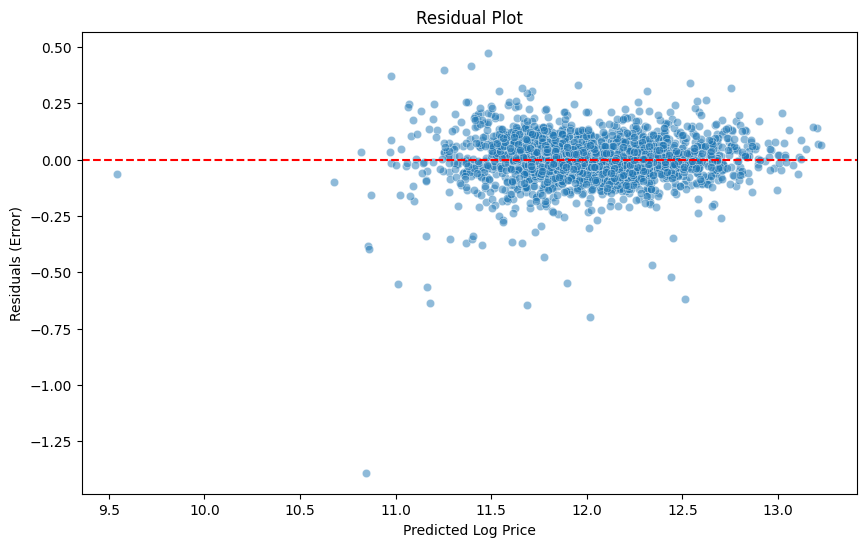

In [9]:
# 1. Generate predictions using the Ridge pipeline (our strongest performer)
best_pipe = ridge_pipe
y_preds_log = best_pipe.predict(X_train)

# 2. Calculate residuals (Actual - Predicted) in log-space
residuals = y_train - y_preds_log

# 3. Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_preds_log, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Log Price')
plt.ylabel('Residuals (Error)')
plt.show()


---

### Reading the Residual Plot

Scan for two things: a "fan" that widens as prices rise, and clusters of points far from the zero line.

Classically, housing models fan out on the *right* — expensive homes are idiosyncratic and hard to price. Interestingly, our cleaning and log transforms appear to have tamed that end: the visible extra scatter in our plot is on the **low-value side**. The model is at its most reliable in the mid-market and at its riskiest pricing the cheapest homes in Ames — worth remembering when we frame the business recommendation below.

So: the model is trustworthy on average, weakest at the low end, and its penalty strength is still a guess. The guess gets fixed in Part 4. First, one more payoff from the model we already have.

## Feature Interpretation: The "So What?"

Accuracy is only half of what stakeholders want; the other half is *why* — which characteristics actually move a house's price? Ordinarily, comparing raw coefficients is a trap (a "per square foot" coefficient and a "per fireplace" coefficient live on incomparable scales). But the `StandardScaler` in our pipeline quietly solved this: every feature was transformed to a z-score, so every coefficient is now a **beta weight** — the effect of a one-standard-deviation change — and beta weights *can* be compared side by side.

We'll pull the coefficients from the Ridge model, our current champion. (Lasso would make this even cleaner — 159 of the coefficients would simply be gone — which is one more reason to revisit it once it's properly tuned in Part 4.)

In [10]:
# 1. Access the model from the pipeline
model_step = ridge_pipe.named_steps['regressor']

# 2. Map coefficients to feature names
feature_names = X_train.columns
coeffs = model_step.coef_

# 3. Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coeffs
})

importance_df = importance_df.sort_values(by='Coefficient', ascending=False)

---

### Visualizing the Big Movers

The top 10 features pushing prices up, and the top 10 dragging them down.

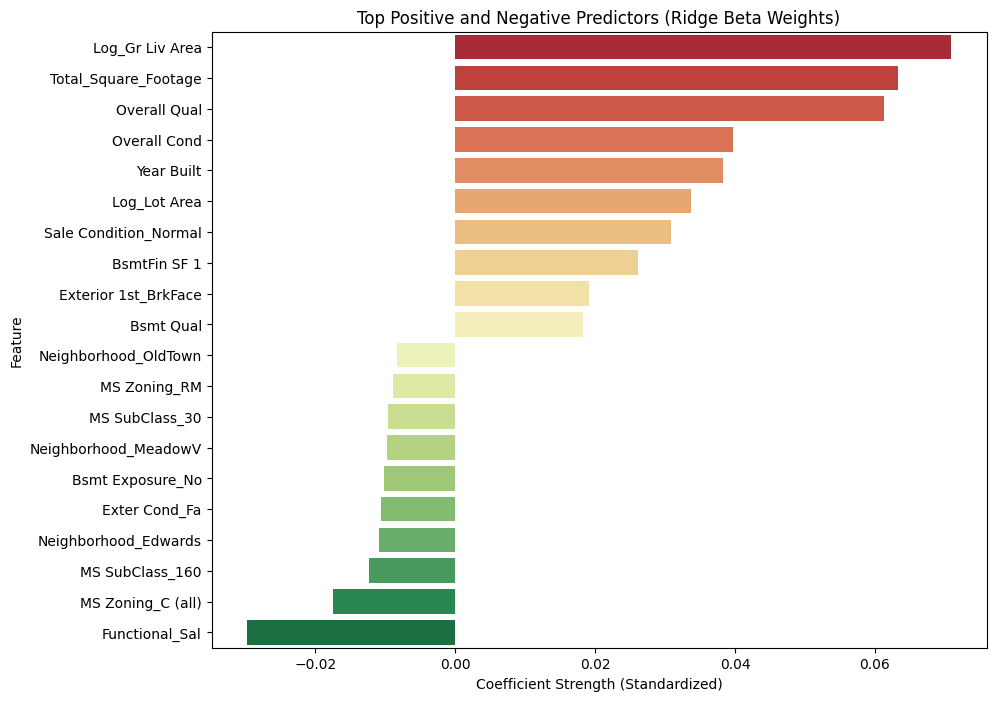

In [11]:
# Get top 10 and bottom 10
top_bottom = pd.concat([importance_df.head(10), importance_df.tail(10)])

plt.figure(figsize=(10, 8))
sns.barplot(data=top_bottom, x='Coefficient', y='Feature', palette='RdYlGn')
plt.title('Top Positive and Negative Predictors (Ridge Beta Weights)')
plt.xlabel('Coefficient Strength (Standardized)')
plt.show()

**Reading the chart:**

* **Positive drivers:** `Log_Gr_Liv_Area`, `Overall Qual`, and `Year Built` dominate — size, quality, and age. No surprises, which is itself informative: the model has independently rediscovered how the Ames market actually works.
* **Negative drivers:** the standout is `Functional_Sal` — "Functionality: Salvage only," the lowest grade on the scale. A salvage-rated house is essentially a teardown: possibly condemned, possibly not legally habitable, and often worth *less* than its land because the buyer inherits the demolition bill. The model has learned to treat that label as the red flag it is.

---

### Business Impact & Recommendation

Where this leaves a hypothetical Ames real-estate investor using our model:

1. **Valuation:** expect the automated estimate to land within about **\$13,000** of the sale price for a typical home.
2. **Renovation strategy:** `Overall Qual` carries more beta weight than room counts — the model says invest in *quality* upgrades before additions.
3. **Risk:** trust the model least on low-priced listings, where the residual analysis found the most volatility.

---

## Conclusion & Next Steps

This notebook leveled up the workflow in three ways: **Pipelines** made cross-validation leak-proof, dollar-space metrics dissolved the Log-Dollar Illusion, and regularization let us use all 225 features without OLS's instability — with Ridge edging out the baseline by ~\$107 per house.

The loose thread is deliberate: every penalty strength in this notebook was a guess, and the leaderboard — especially Lasso's last place — reflects our guesses as much as the models. **Part 4** hands the guessing to the machine: **GridSearchCV** will search the alpha space systematically, and the Lasso we wrote off may get its redemption.